<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulacion-I/blob/main/Estimaci%C3%B3n_de_Integrales_c_exitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimación de integrales

Se quiere estimar:

$$\int_0^{\frac{\pi}{2}}sen(x) dx$$

Usaremos el método de Montecarlo de acierto y error (la idea de los darnos), nuestro estimar será:
 $$\hat{I}=\frac{n}{N}(\frac{\pi}{2})$$

 Con $n$ siendo el número de éxitos y $N$ el número total de simulaciones.

In [12]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import random as r

Se ejemplifica lo que se quiere hacer, pero para un solo punto:

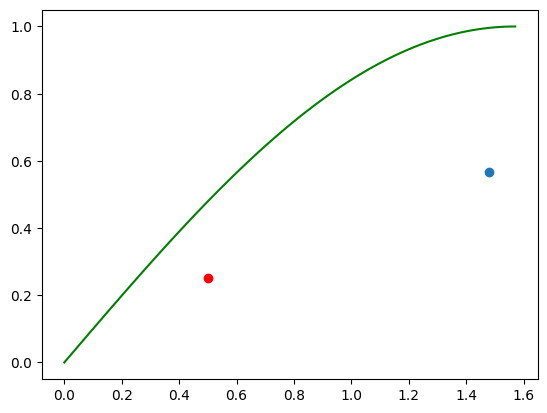

In [13]:
x=np.linspace(0, np.pi/2,100)
plt.plot(x,np.sin(x), color='green')
plt.scatter(0.5,0.25, color='red') # Este punto está en la zona de aciertos (se marca con rojo)
plt.scatter(r.uniform(0, np.pi/2), r.random())

Defino la función:

In [11]:
def dardos(x_1,x_2,f,N):
    exitos=0
    pex=[]
    pf=[]
    y_1=0
    x_max = np.linspace(x_1, x_2, 1000)
    y_2=max(f(x_max))

    for i in range (N):
        x=r.uniform(x_1,x_2)
        y=r.uniform(y_1,y_2)
        if y<=f(x):
           exitos+=1
           pex.append((x,y))
        else:
           pf.append((x,y))

    I = (exitos / N)*(np.pi/2)
    print(f"El valor estimado de la integral es:", I)

    return pex, pf

Llamo la función, los argumentos son $0, \frac{\pi}{2}, sen(x)$ y $n=1000$

In [15]:
prueba=dardos(0, np.pi/2, np.sin, 1000)

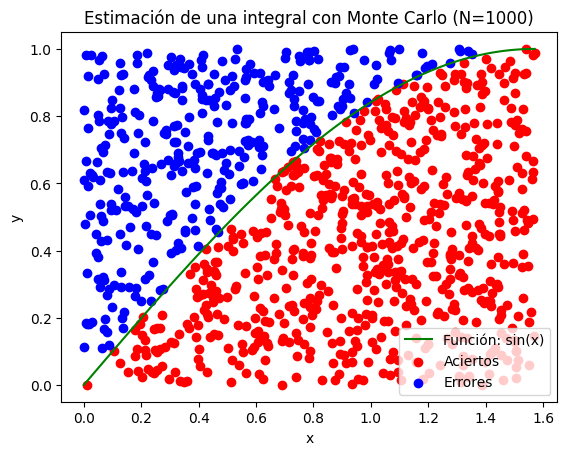

In [23]:
x_plot = np.linspace(0, np.pi/2, 100)
plt.plot(x_plot, np.sin(x_plot), color='green', label=('Función: sin(x)'))

pex = prueba[1]
pf = prueba[2]
n = 1000

plt.scatter([p[0] for p in pex], [p[1] for p in pex], color='red', label='Aciertos')
plt.scatter([p[0] for p in pf], [p[1] for p in pf], color='blue', label='Errores')
plt.title(f'Estimación de una integral con Monte Carlo (N={n})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

¿Qué valor debe ser $n$? y ¿Qué valor debe reportarse como respuesta?

Defino la función que hará el vector de experimentos con  M  entradas:

In [29]:
def experimento(M):
    L=[]
    for i in range(M):
        I=dardos(0, np.pi/2, np.sin, (i+1)*2)
        L.append(I)
    return L

Para el ejemplo, vi al cambiar el valor de M que el valor que requiere menos recursos computacionales, es  M=500:

In [48]:
E=experimento(500)

Ahora será graficado el vector de experimentos:

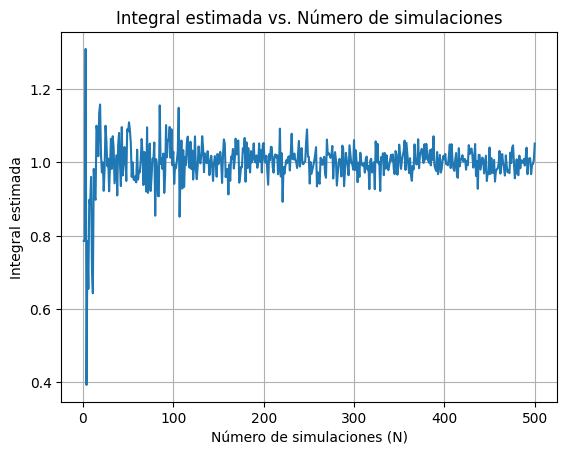

In [49]:
int_es = [item[0] for item in E]

N = [(i + 1) for i in range(len(E))]

plt.plot(N, int_es)
plt.xlabel('Número de simulaciones (N)')
plt.ylabel('Integral estimada')
plt.title('Integral estimada vs. Número de simulaciones')
plt.grid(True)
plt.show()

Se calcula la media del vector de experimentos:


In [56]:
me_int = np.mean(int_es)
print(f"El promedio de la integral con M simulaciones: {me_int}")

El promedio de la integral con M simulaciones: 0.9985864642587742


Defino la función que hará las $F$ simulaciones:

In [65]:
def simulaci(F):
    Li=[]
    for i in range(F):
        ex = experimento(500)
        int_exp = [item[0] for item in ex]
        e = np.mean(int_exp)
        Li.append(e)
    return Li

Llamo a la función y haremos $100$ simulaciones:

In [64]:
p=simulaci(100)

Ahora un histograma de las simulaciones:

(array([ 1.,  0.,  3., 14., 12., 28., 25., 12.,  2.,  3.]),
 array([0.98896009, 0.99083984, 0.99271959, 0.99459935, 0.9964791 ,
        0.99835885, 1.0002386 , 1.00211835, 1.0039981 , 1.00587785,
        1.0077576 ]),
 <BarContainer object of 10 artists>)

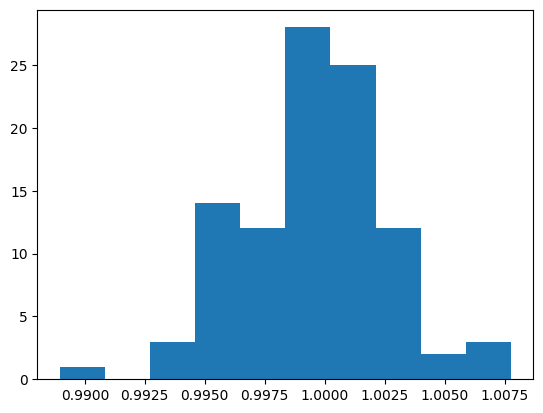

In [66]:
plt.hist(p)